In [11]:
import numpy as np
from numpy.lib import recfunctions as rfn

import matplotlib.pyplot as plt
import candel

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
config_SH0ES = "/Users/rstiskalek/Projects/CANDEL/scripts/runs/config_shoes.toml"
data_SH0ES = candel.pvdata.load_SH0ES_from_config(config_SH0ES)

2025-12-15 10:18:26 warning: zero width found in the priors. Setting it to 1e-5.
2025-12-15 10:18:26 indices of zero width: [44]
2025-12-15 10:18:26 found zero-width prior at index 44. Setting it to 0.
2025-12-15 10:18:26 Masking Cepheids with cz_cmb > 5000 km/s: Keeping 37 out of 37.


In [19]:
names = [str(k).replace("mu_", "") for k in data_SH0ES["host_names"]]

for i, name in enumerate(names):
    if name == "M1337":
        names[i] = "Mrk1337"


In [25]:
data_NED = np.asanyarray([candel.util.query_ned_cmb_redshift_radec(name) for name in names])

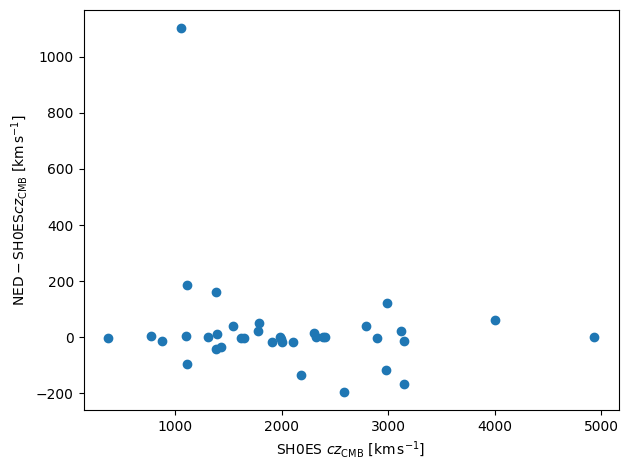

In [45]:
plt.figure()

plt.scatter(data_SH0ES["czcmb_cepheid_host"], data_NED[:, 0] - data_SH0ES["czcmb_cepheid_host"])

plt.xlabel(r"SH0ES $cz_{\rm CMB} ~ [\mathrm{km} \, \mathrm{s}^{-1}]$")
plt.ylabel(r"$\mathrm{NED}-\mathrm{SH0ES} cz_{\rm CMB} ~ [\mathrm{km} \, \mathrm{s}^{-1}]$")
plt.tight_layout()

plt.savefig("/Users/rstiskalek/Downloads/compare_redshift_SH0ES_NED.png", dpi=300)

plt.show()

In [47]:
np.where(np.abs(data_NED[:, 0] - data_SH0ES["czcmb_cepheid_host"]) > 500)

(array([22]),)

In [48]:
names[22]

'N4536'

In [50]:
data_NED[22, :], data_SH0ES["czcmb_cepheid_host"][22]

(array([2151.05804714,  188.61278   ,    2.18824   ]), 1049.2736029999999)